<a href="https://colab.research.google.com/github/Dimas0824/PCVK/blob/main/Pertemuan5/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D-1 PERCOBAAN HISTOGRAM

1. Import library

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

Membuat histogram citra seperti berdasarkan flowchart di bawah ini : (Gunakan
gambar lena.jpg) <br>
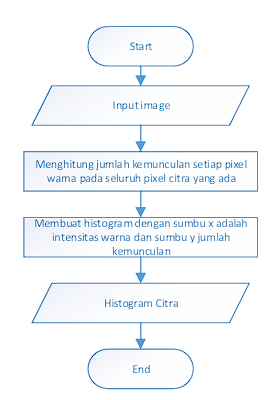

<BarContainer object of 256 artists>

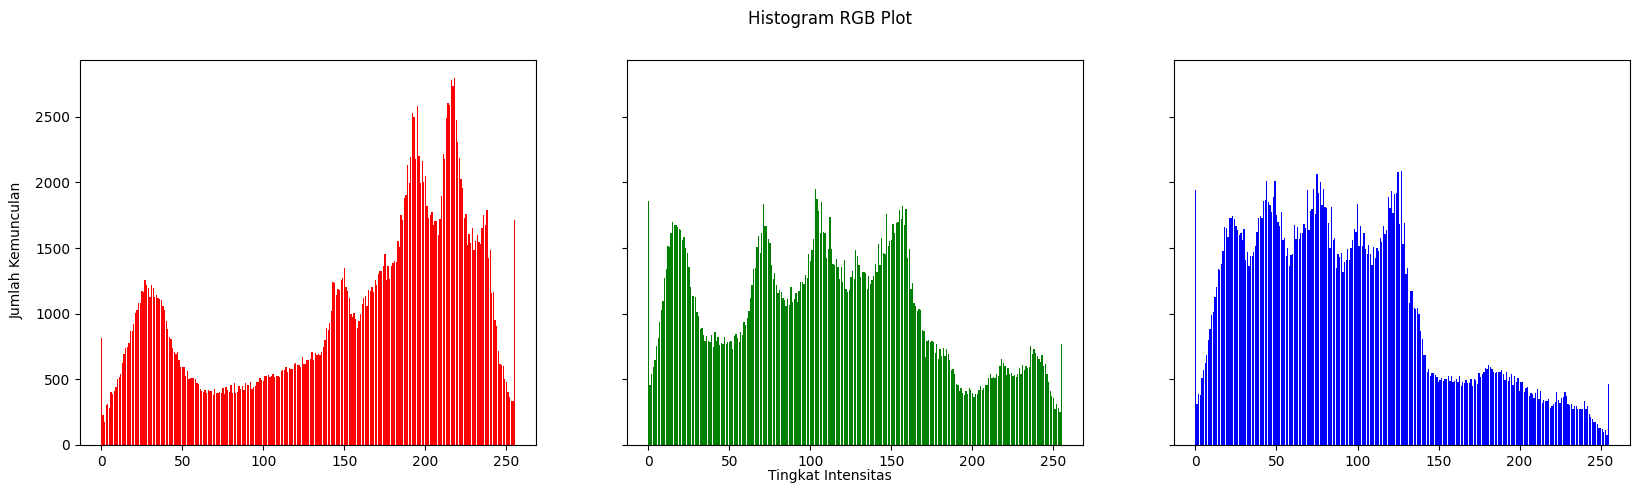

In [ ]:
# input image dan baca
img = cv.imread ('/content/drive/MyDrive/PCVK/Images/lena.jpg')

# 2. Konversi dari format BGR (default OpenCV) ke RGB
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 3. Ambil dimensi citra: tinggi, lebar, jumlah channel
height, width, depth = np.shape(img)

# 4. Buat array untuk range intensitas pixel (0–255)
names = np.arange(256)

# 5. Inisialisasi array histogram (semua bernilai 0 di awal)
red   = [0] * 256
green = [0] * 256
blue  = [0] * 256

# 6. Looping semua pixel citra
for y in range(0, height):
    for x in range(0, width):
        # Hitung frekuensi untuk setiap channel warna
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

# 7. Plot hasil histogram
names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')

# Label sumbu Y
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')

# Label sumbu X
fig.text(0.5, 0.04, 'Tingkat Intensitas', ha='center')

# 8. Tampilkan histogram untuk tiap channel
axs[0].bar(names, red,   color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue,  color='blue')

PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

    jawab: dari hasil perbandingan histogram dibawah maka dapat disimpulkan tidak ada perbedaan dan outputnya sama persis seperti sebelumnya.


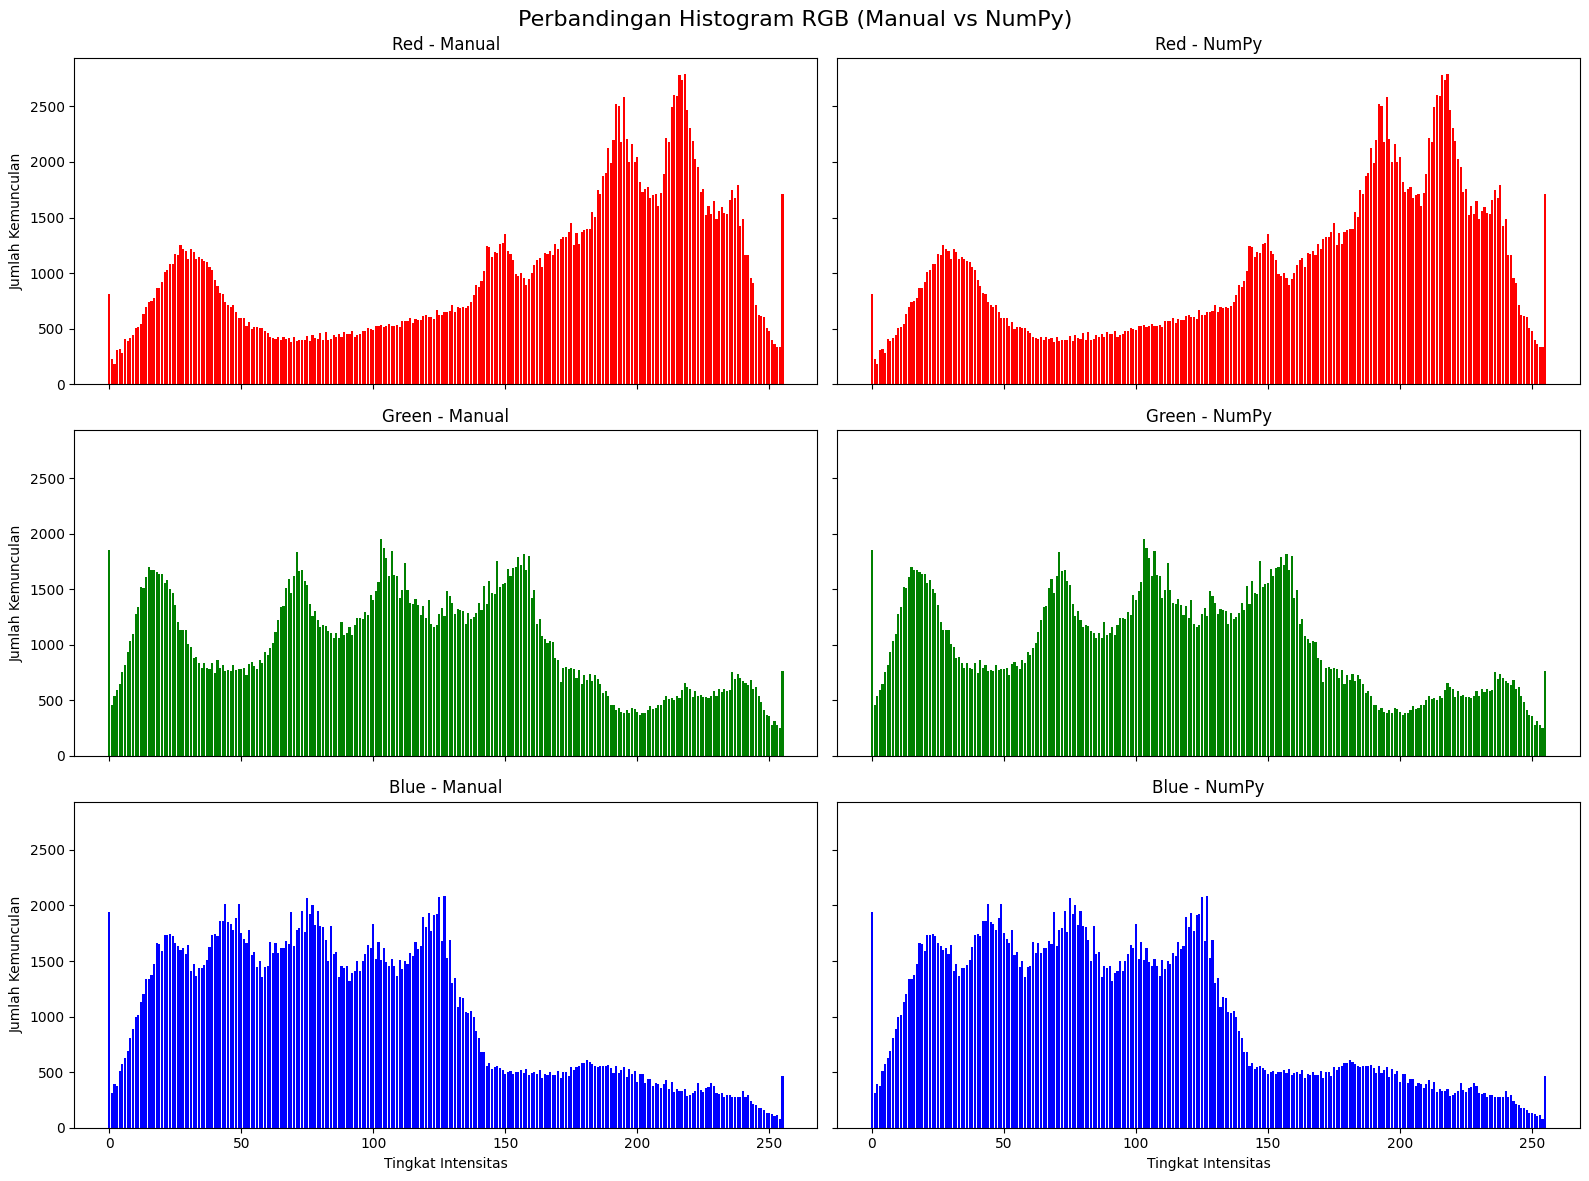

In [ ]:
# --- Histogram Manual ---
red_manual   = [0] * 256
green_manual = [0] * 256
blue_manual  = [0] * 256

for y in range(height):
    for x in range(width):
        red_manual[img[y, x, 0]]   += 1
        green_manual[img[y, x, 1]] += 1
        blue_manual[img[y, x, 2]]  += 1

# --- Histogram dengan numpy.histogram ---
red_np, _   = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green_np, _ = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue_np, _  = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

# 2. Plot hasil perbandingan
fig, axs = plt.subplots(3, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle("Perbandingan Histogram RGB (Manual vs NumPy)", fontsize=16)

# --- Red Channel ---
axs[0,0].bar(names, red_manual, color='red')
axs[0,0].set_title("Red - Manual")
axs[0,1].bar(names, red_np, color='red')
axs[0,1].set_title("Red - NumPy")

# --- Green Channel ---
axs[1,0].bar(names, green_manual, color='green')
axs[1,0].set_title("Green - Manual")
axs[1,1].bar(names, green_np, color='green')
axs[1,1].set_title("Green - NumPy")

# --- Blue Channel ---
axs[2,0].bar(names, blue_manual, color='blue')
axs[2,0].set_title("Blue - Manual")
axs[2,1].bar(names, blue_np, color='blue')
axs[2,1].set_title("Blue - NumPy")

# Label sumbu
for ax in axs[:,0]:
    ax.set_ylabel("Jumlah Kemunculan")
for ax in axs[2,:]:
    ax.set_xlabel("Tingkat Intensitas")

plt.tight_layout()
plt.show()

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

    jawab: Berdasarkan histogram yang ditampilkan, citra hasil menunjukkan kecenderungan terang karena sebagian besar piksel berada pada intensitas tinggi, mendekati nilai 250. Meskipun distribusinya tidak sepenuhnya sempit, intensitas tetap terkonsentrasi di area terang, sehingga kontras antara area gelap dan terang kurang optimal. Secara visual, citra tampak sedikit overexposed—bagian-bagian yang sangat terang, seperti latar belakang atau area wajah, cenderung kehilangan detail halus. Hal ini mengindikasikan bahwa proses sebelumnya (misalnya equalization atau pencahayaan saat pengambilan gambar) tidak secara signifikan meningkatkan kualitas informasi visual, dan justru berisiko mengurangi kedalaman tekstur pada area terang.

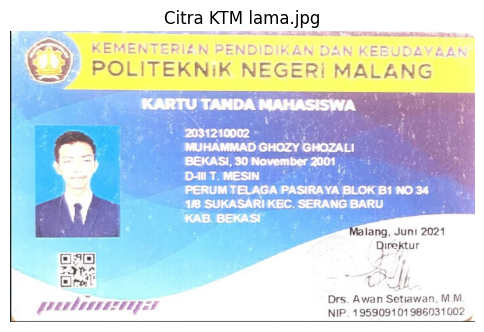

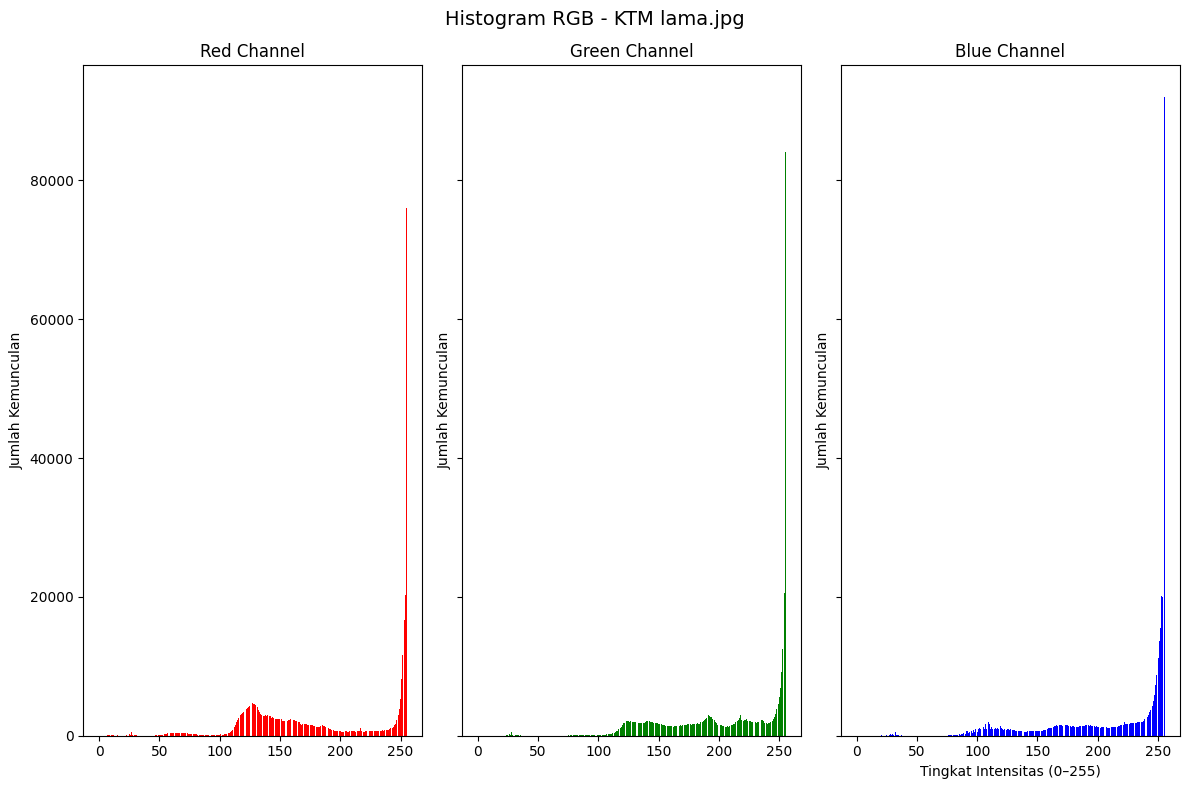

In [ ]:
# 1. Load citra KTM
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2. Hitung histogram per channel dengan NumPy
red_hist, _   = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green_hist, _ = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue_hist, _  = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])
names = np.arange(256)

# 3. Plot citra asli
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Citra KTM lama.jpg")
plt.axis("off")
plt.show()

# 4. Plot histogram RGB
fig, axs = plt.subplots(1, 3, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("Histogram RGB - KTM lama.jpg", fontsize=14)

axs[0].bar(names, red_hist, color='red')
axs[0].set_title("Red Channel")

axs[1].bar(names, green_hist, color='green')
axs[1].set_title("Green Channel")

axs[2].bar(names, blue_hist, color='blue')
axs[2].set_title("Blue Channel")
axs[2].set_xlabel("Tingkat Intensitas (0–255)")

for ax in axs:
    ax.set_ylabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()

D-2 PERCOBAAN HISTOGRAM EQUALIZATION

1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan
flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

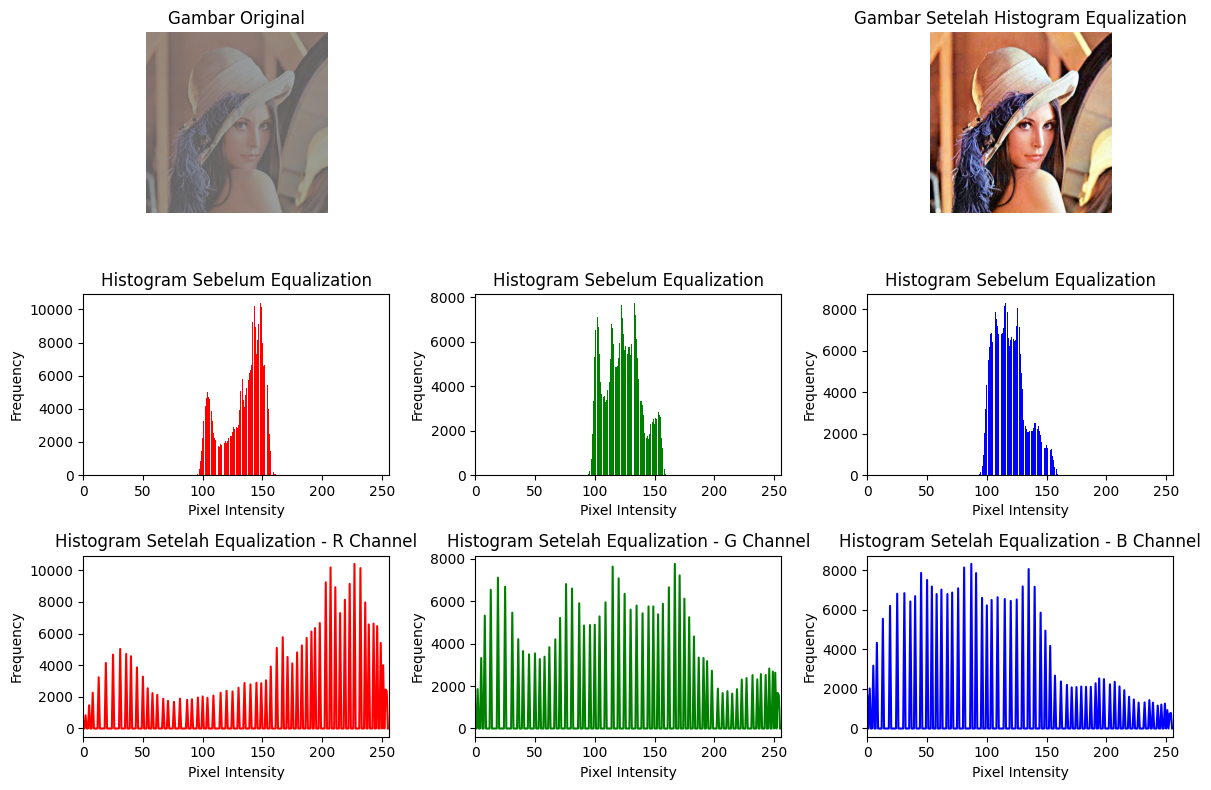

In [ ]:
# Step 1: Load lena_lc
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 2: Menghitung jumlah kemunculan setiap pixel warna (frekuensi)
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Step 3: Menghitung penjumlahan kumulatif dari frekuensi
cdf = hist.cumsum()

# Step 4: Normalisasi, membagi dengan jumlah total pixel
cdf_normalized = cdf * hist.max() / cdf.max()

# Step 5: Implementasi rumus k0, Normalisasi CDF
cdf_m = np.ma.masked_equal(cdf, 0)  # Mengabaikan nilai 0
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())  # Rumus Normalisasi
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')  # Mengisi kembali nilai yang diabaikan

# Step 6: Menerapkan CDF hasil equalization pada gambar
img_equalized = cdf_final[img]

plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(img_equalized)
plt.title('Gambar Setelah Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(3, 3, 3 + i + 1)
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.bar(range(256), hist.flatten(), color=color)
    plt.title('Histogram Sebelum Equalization')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(3, 3, 6 + i + 1)  # 3 rows, 2 columns
    hist_eq = cv.calcHist([img_equalized], [i], None, [256], [0, 256])
    plt.plot(hist_eq, color=color)
    plt.title(f'Histogram Setelah Equalization - {color.upper()} Channel')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini. <br>
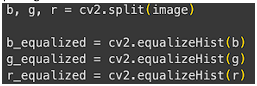 <br>
Lengkapi potongan kode tersebut! Bandingkan hasilnya. Apakah output muncul sama?

    jawab: output yang dihasilkan dari Langkah D2 nomor 1 dengan nomor 2 ini berbeda, hasil penggunaan open cv qualizeHist cenderung berwarna biru dan tidak stabil sesuai warna aslinya yang hanya kekurangan contrast

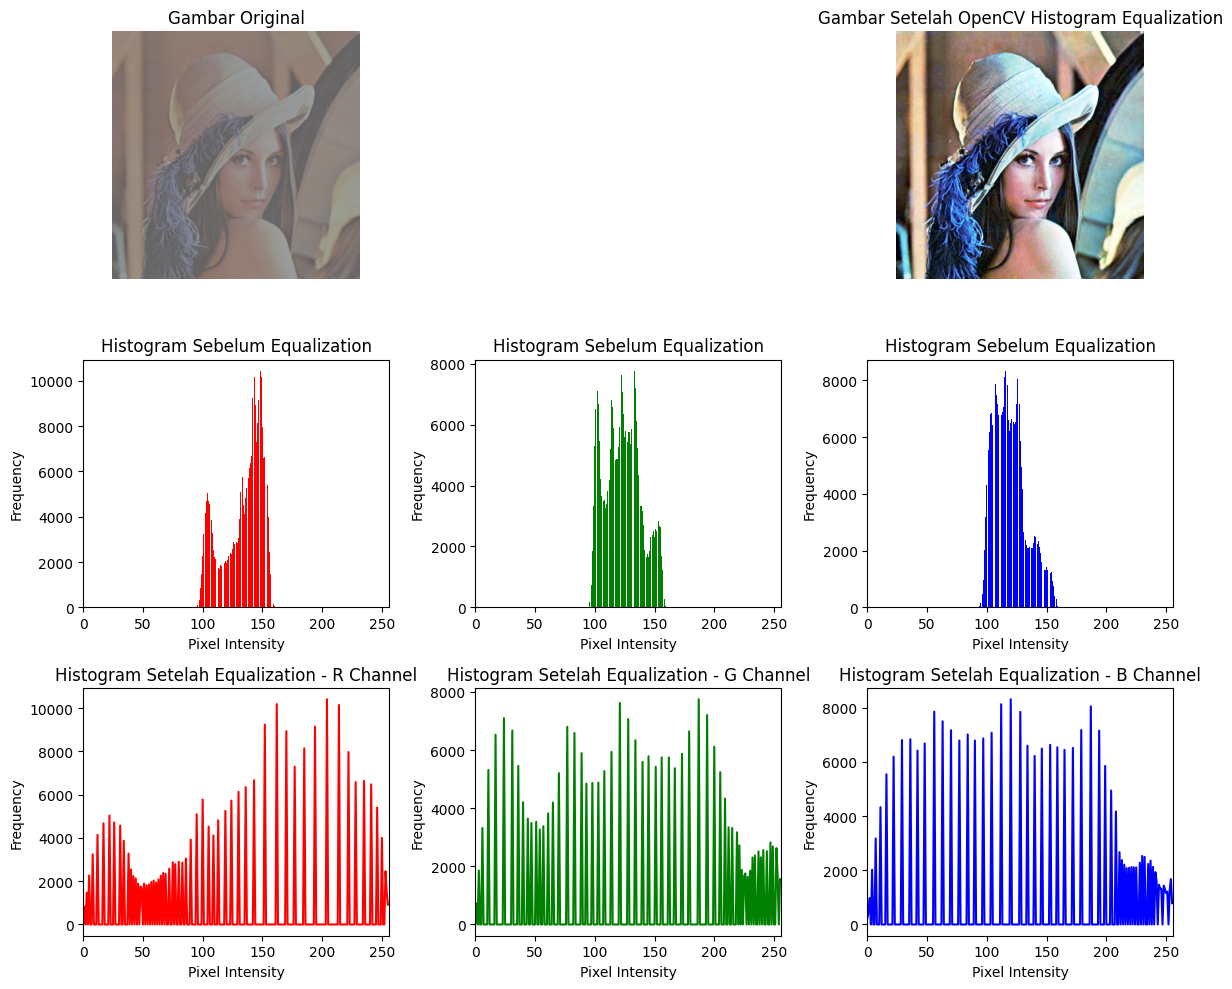

In [ ]:
# Step 3: Histogram equalization using cv2.equalizeHist
img_equalized = np.zeros_like(img)
for i in range(3):
    img_equalized[:, :, i] = cv.equalizeHist(img[:, :, i])

# Step 4: Menampilkan gambar asli dan gambar setelah equalization
plt.figure(figsize=(12, 10))

# Original Image
plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

# OpenCV Histogram Equalized Image
plt.subplot(3, 3, 3)
plt.imshow(img_equalized)
plt.title('Gambar Setelah OpenCV Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(3, 3, 3 + i + 1)
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.bar(range(256), hist.flatten(), color=color)
    plt.title('Histogram Sebelum Equalization')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(3, 3, 6 + i + 1)  # 3 rows, 2 columns
    hist_eq = cv.calcHist([img_equalized], [i], None, [256], [0, 256])
    plt.plot(hist_eq, color=color)
    plt.title(f'Histogram Setelah Equalization - {color.upper()} Channel')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


PERTANYAAN PRAKTIKUM D2

1. Perbandingan Citra Lena

    a. Gunakan hasil histogram equalization pada citra lena.jpg.

    b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

    c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

    jawab: Nilai PSNR sebesar 29,26 dB menunjukkan kualitas gambar yang cukup tinggi. Sementara itu, hasil dari histogram equalization tidak memberikan perubahan visual yang signifikan dibandingkan dengan citra asli. Hal ini disebabkan oleh distribusi kontras pada gambar asli yang sudah cukup baik, sehingga proses equalization hanya berfungsi untuk meratakan distribusi intensitas secara lebih halus tanpa merusak tampilan asli maupun menambahkan informasi baru yang berarti.

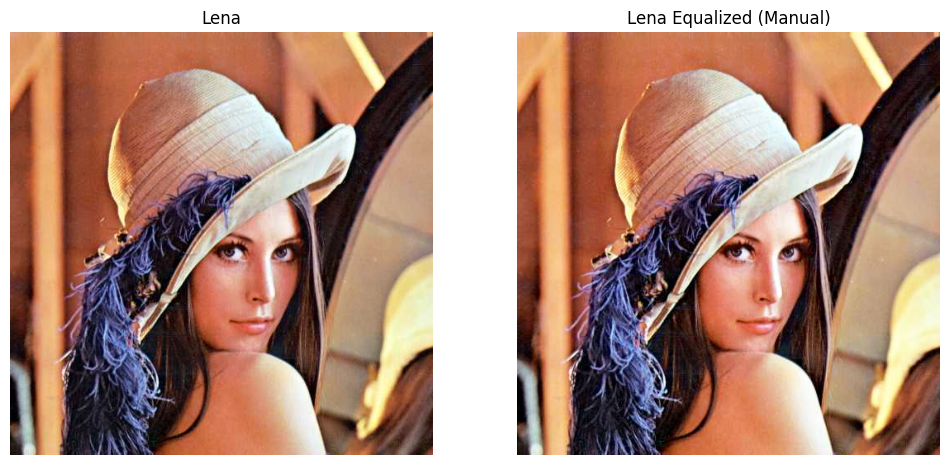

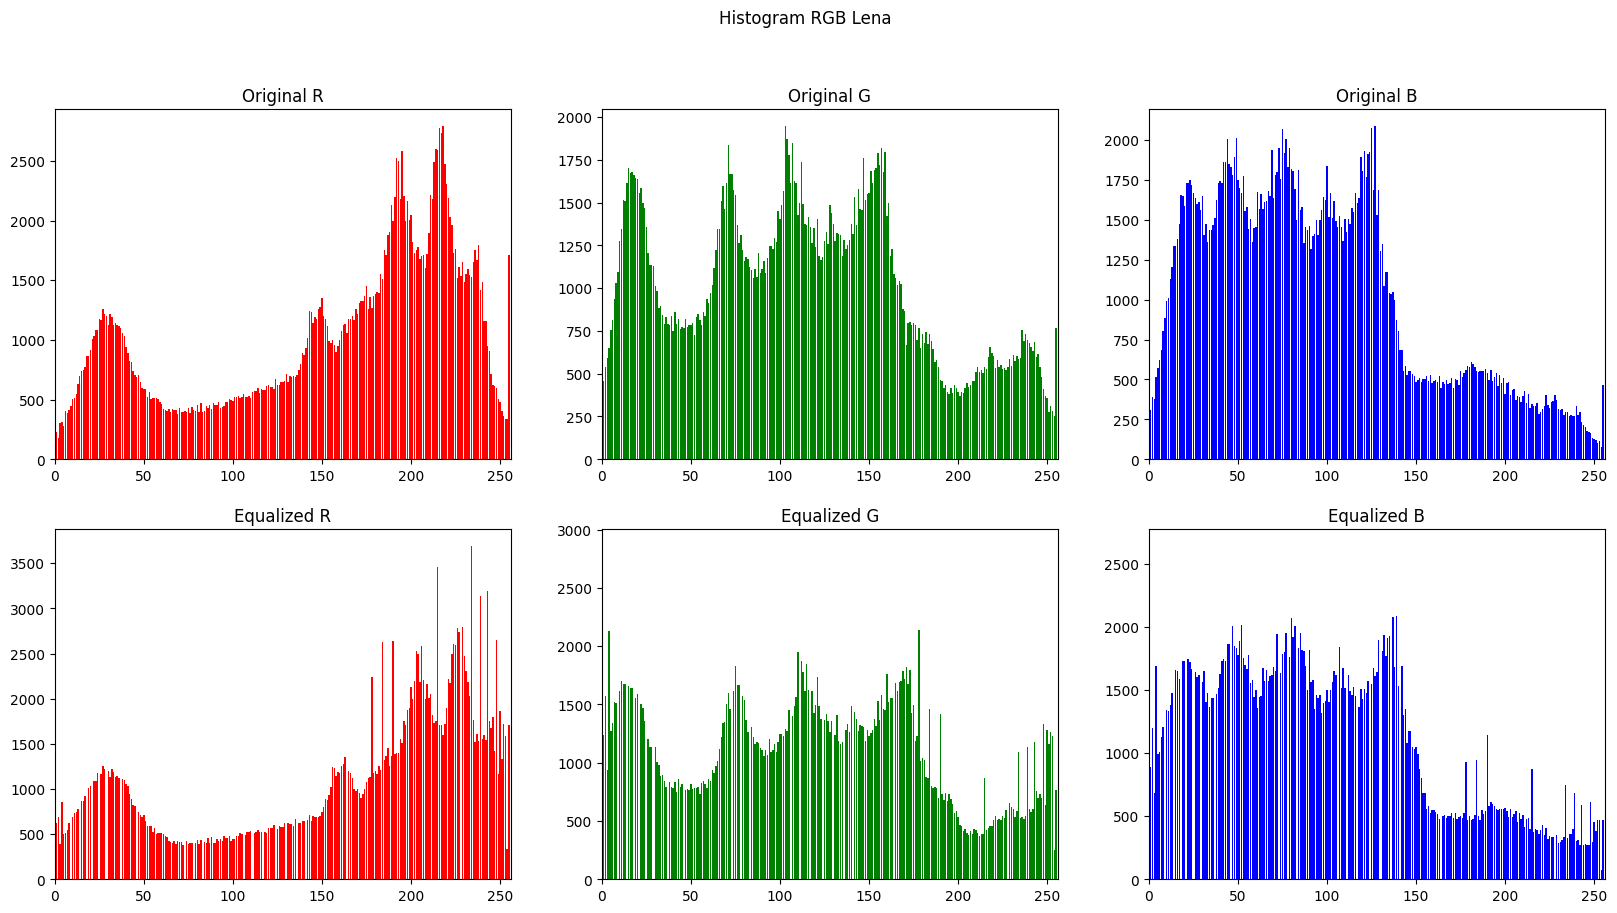

PSNR antara Lena asli & equalized: 29.26 dB


In [ ]:
# Step 1: Load lena low contrast
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 2: Hitung histogram global
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Step 3: Hitung CDF
cdf = hist.cumsum()

# Step 4: Normalisasi
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

# Step 5: Equalization
img_equalized = cdf_final[img]

# --- Visualisasi gambar ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Lena')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized)
plt.title('Lena Equalized (Manual)')
plt.axis('off')
plt.show()

# --- Histogram sebelum & sesudah ---
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
colors = ('r','g','b')

for i, col in enumerate(colors):
    axs[0,i].bar(range(256), cv.calcHist([img],[i],None,[256],[0,256]).flatten(), color=col)
    axs[0,i].set_title(f'Original {col.upper()}')
    axs[0,i].set_xlim([0,256])

    axs[1,i].bar(range(256), cv.calcHist([img_equalized],[i],None,[256],[0,256]).flatten(), color=col)
    axs[1,i].set_title(f'Equalized {col.upper()}')
    axs[1,i].set_xlim([0,256])

plt.suptitle("Histogram RGB Lena")
plt.show()

# --- Hitung PSNR dengan Lena asli ---
lena_original = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
lena_original = cv.cvtColor(lena_original, cv.COLOR_BGR2RGB)

mse = np.mean((lena_original.astype(np.float64) - img_equalized.astype(np.float64)) ** 2)
PIXEL_MAX = 255.0
psnr = 20 * np.log10(PIXEL_MAX / np.sqrt(mse))
print(f"PSNR antara Lena asli & equalized: {psnr:.2f} dB")

2. Gunakan Citra KTM Lama.jpg

    a. Terapkan histogram equalization pada citra KTM lama.jpg.

    b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
    dalam satu layout.

    c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
    Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
    teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
    informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

    jawab:

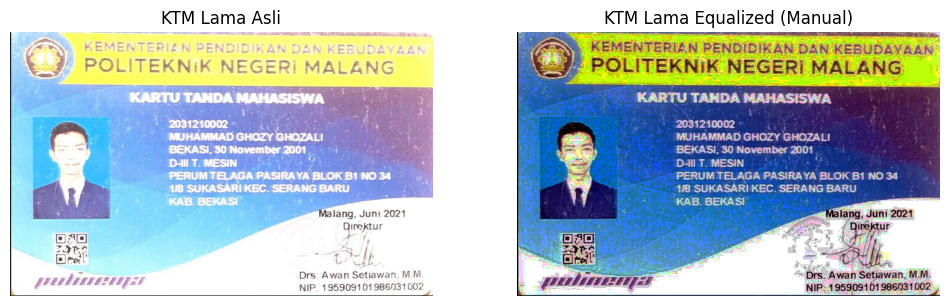

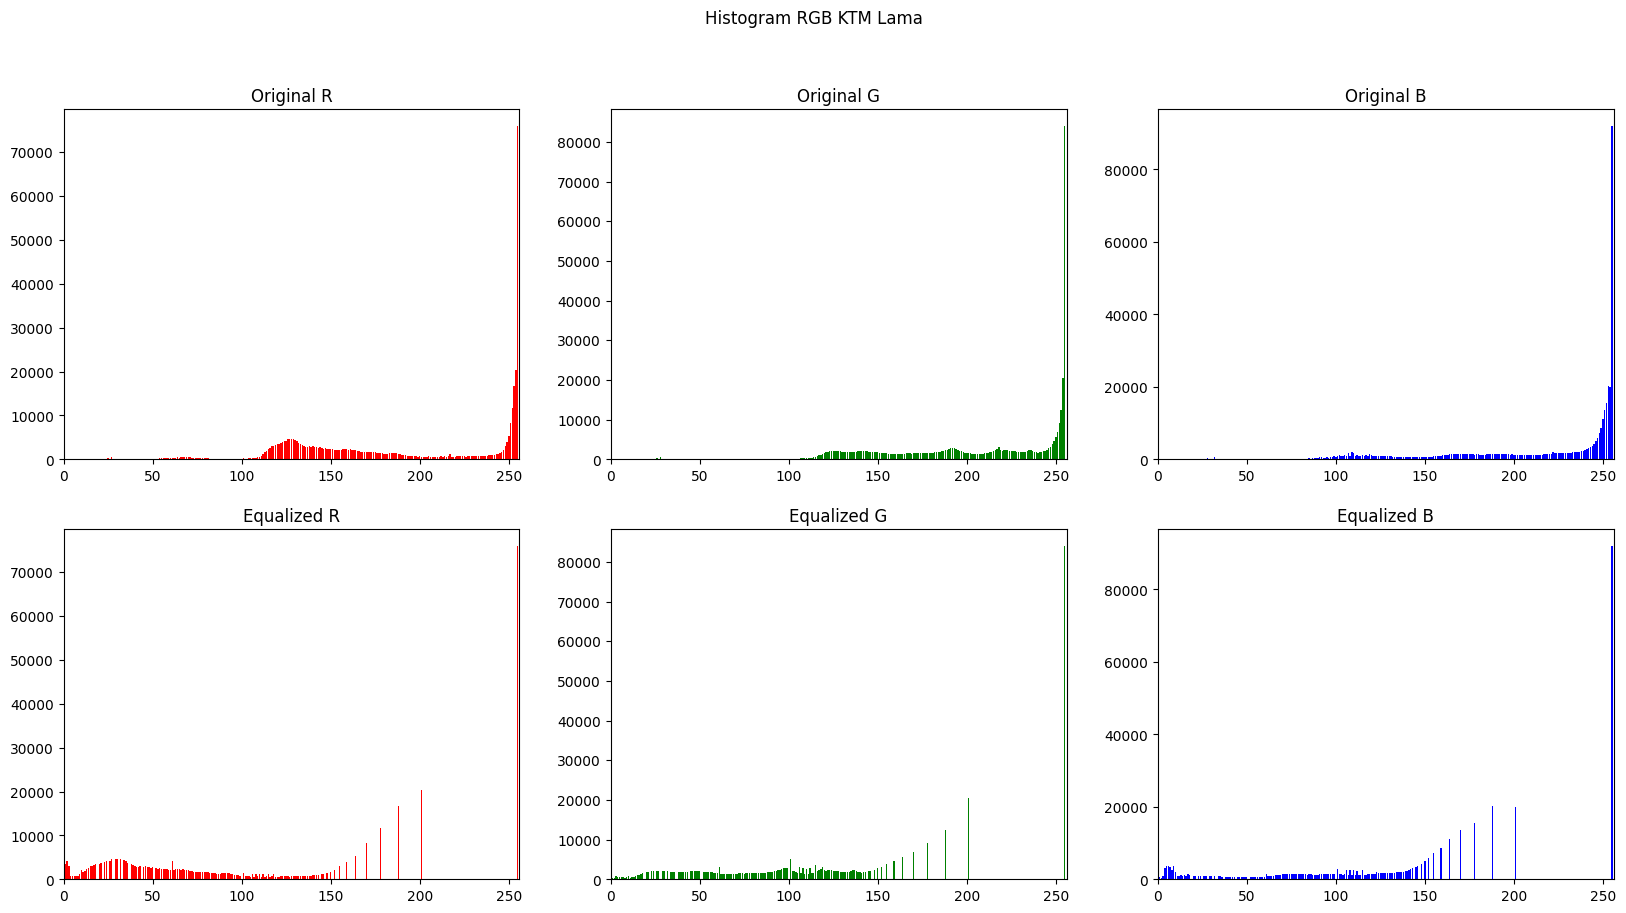

In [ ]:
# Step 1: Load KTM Lama (warna)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 2: Hitung histogram global
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Step 3: Hitung CDF
cdf = hist.cumsum()

# Step 4: Normalisasi CDF
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

# Step 5: Equalization manual (RGB langsung)
img_equalized = cdf_final[img]

# --- Visualisasi gambar ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('KTM Lama Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized)
plt.title('KTM Lama Equalized (Manual)')
plt.axis('off')
plt.show()

# --- Histogram sebelum & sesudah ---
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
colors = ('r','g','b')

for i, col in enumerate(colors):
    axs[0,i].bar(range(256), cv.calcHist([img],[i],None,[256],[0,256]).flatten(), color=col)
    axs[0,i].set_title(f'Original {col.upper()}')
    axs[0,i].set_xlim([0,256])

    axs[1,i].bar(range(256), cv.calcHist([img_equalized],[i],None,[256],[0,256]).flatten(), color=col)
    axs[1,i].set_title(f'Equalized {col.upper()}')
    axs[1,i].set_xlim([0,256])

plt.suptitle("Histogram RGB KTM Lama")
plt.show()

D-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

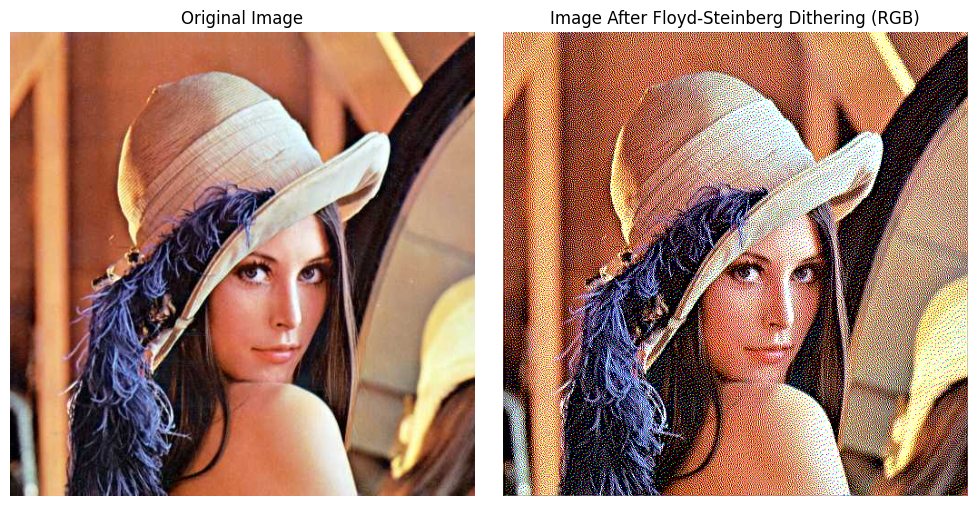

In [ ]:
# Floyd-Steinberg dithering matrix
fs_matrix = np.array([[0, 0, 7],
                      [3, 5, 1]]) / 16

# Load the image in RGB format
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi gambar ke RGB

# Normalize the image to have pixel values between 0 and 1
img = img.astype(np.float32) / 255.0

# Get the dimensions of the image
rows, cols, channels = img.shape

# Create a copy of the image to apply the dithering
dithered_img = np.copy(img)

# Apply Floyd-Steinberg dithering on each channel independently
for y in range(rows - 1):
    for x in range(1, cols - 1):
        for c in range(channels):  # Iterasi melalui setiap kanal warna (R, G, B)
            old_pixel = dithered_img[y, x, c]
            new_pixel = np.round(old_pixel)  # Quantize to either 0 or 1
            dithered_img[y, x, c] = new_pixel
            error = old_pixel - new_pixel

            # Distribute the error to neighboring pixels
            dithered_img[y, x+1, c] += error * 7 / 16
            dithered_img[y+1, x-1, c] += error * 3 / 16
            dithered_img[y+1, x, c]   += error * 5 / 16
            dithered_img[y+1, x+1, c] += error * 1 / 16

# Convert dithered image back to 0-255 range for display
dithered_img = (dithered_img * 255).astype(np.uint8)

# Display the original and dithered images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dithered_img)
plt.title('Image After Floyd-Steinberg Dithering (RGB)')
plt.axis('off')

plt.tight_layout()
plt.show()


2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

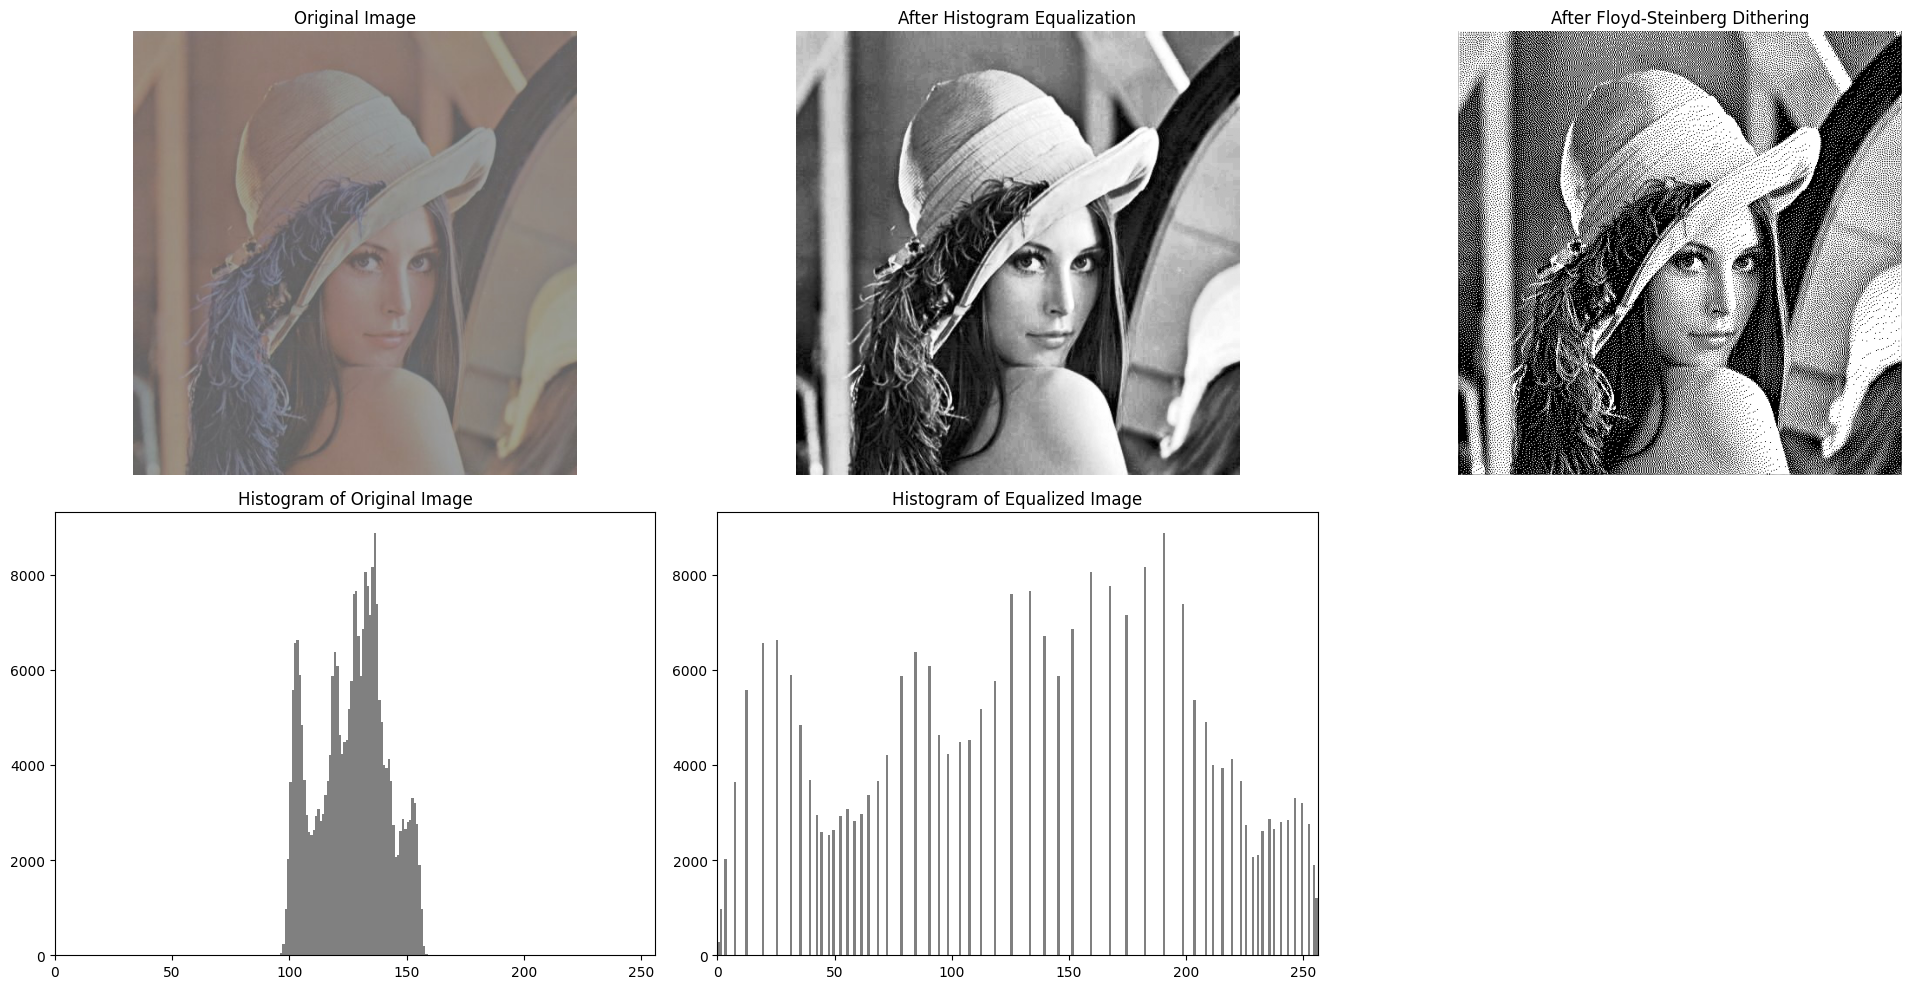

In [ ]:
# Load the image
img_path = '/content/drive/MyDrive/PCVK/Images/lena_lc.jpg'  # Sesuaikan dengan path file
img = cv.imread(img_path)
img_ori = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert the image to grayscale
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply histogram equalization
equalized_img = cv.equalizeHist(gray_img)

# Floyd-Steinberg dithering matrix
fs_matrix = np.array([[0, 0, 7],
                      [3, 5, 1]]) / 16

# Normalize the equalized image to have pixel values between 0 and 1
img_normalized = equalized_img.astype(np.float32) / 255.0

# Get the dimensions of the image
rows, cols = img_normalized.shape

# Create a copy of the image to apply the dithering
dithered_img = np.copy(img_normalized)

# Apply Floyd-Steinberg dithering
for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered_img[y, x]
        new_pixel = np.round(old_pixel)  # Quantize to either 0 or 1
        dithered_img[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Distribute the error to neighboring pixels
        dithered_img[y, x + 1] += error * 7 / 16
        dithered_img[y + 1, x - 1] += error * 3 / 16
        dithered_img[y + 1, x] += error * 5 / 16
        dithered_img[y + 1, x + 1] += error * 1 / 16

# Convert dithered image back to 0-255 range for display
dithered_img = (dithered_img * 255).astype(np.uint8)

# Plot original, equalized, dithered images and their histograms
plt.figure(figsize=(20, 10))

# Original Image and Histogram
plt.subplot(2, 3, 1)
plt.imshow(img_ori)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Original Image')
plt.xlim([0, 256])

# Equalized Image and Histogram
plt.subplot(2, 3, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('After Histogram Equalization')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.hist(equalized_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Equalized Image')
plt.xlim([0, 256])

# Dithered Image and Histogram
plt.subplot(2, 3, 3)
plt.imshow(dithered_img, cmap='gray')
plt.title('After Floyd-Steinberg Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()